# Comparador Interactivo de Modelos
Esta notebook te permite abrir una ventana de Windows para seleccionar una foto de tu computadora, pasársela a los 3 modelos, y ver qué opina cada uno.

In [1]:
import json
import tkinter as tk
from tkinter import filedialog
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# Ocultar warnings de TF
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("Cargando el diccionario de clases...")
with open("mapeo_clases_CM.json", "r", encoding="utf-8") as f:
    class_indices = json.load(f)["index_to_class"]
class_labels = {int(k): v for k, v in class_indices.items()}

print("Cargando modelo VGG16...")
model_vgg = load_model("mejor_modelo_VGG16.keras", compile=False)

print("Cargando modelo MobileNetV2...")
model_mb = load_model("mejor_modelo_MBNet.keras", compile=False)

print("Cargando modelo Custom...")
model_cm = load_model("mejor_modelo_CM.keras", compile=False)

print("¡Todo listo! Ejecutá la celda de abajo para probar imágenes.")

Cargando el diccionario de clases...
Cargando modelo VGG16...
Cargando modelo MobileNetV2...
Cargando modelo Custom...
¡Todo listo! Ejecutá la celda de abajo para probar imágenes.


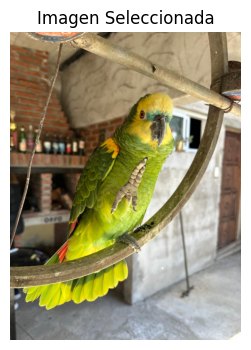

| Custom Model    | Predicción: MARIPOSA     | Confianza:  65.23% |
| VGG16           | Predicción: GALLINA      | Confianza:  67.87% |
| MobileNetV2     | Predicción: PERRO        | Confianza:  66.53% |


In [8]:
def probar_imagen():
    # 1. Abrir explorador de archivos de Windows
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    file_path = filedialog.askopenfilename(
        title="Seleccioná una foto de un animal",
        filetypes=[("Imágenes", "*.jpg *.jpeg *.png")]
    )
    root.destroy()
    
    if not file_path:
        print("Operación cancelada.")
        return
        
    # 2. Cargar y mostrar la imagen
    img = Image.open(file_path).convert('RGB')
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Imagen Seleccionada")
    plt.show()
    
    # 3. Preprocesamiento (Redimensionar a 224x224)
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized, dtype=np.float32)
    img_batch = np.expand_dims(img_array, axis=0) # Formato batch: (1, 224, 224, 3)
    
    # 4. Acondicionamiento específico para CADA modelo (¡Clave de arquitectura!)
    img_cm = img_batch / 255.0  # Custom model usa normalización [0, 1]
    img_vgg = tf.keras.applications.vgg16.preprocess_input(img_batch.copy())
    img_mb = tf.keras.applications.mobilenet_v2.preprocess_input(img_batch.copy())
    
    # 5. Predicciones
    pred_cm = model_cm.predict(img_cm, verbose=0)[0]
    pred_vgg = model_vgg.predict(img_vgg, verbose=0)[0]
    pred_mb = model_mb.predict(img_mb, verbose=0)[0]
    
    # Función para imprimir resultados
    def mostrar_resultado(nombre, pred):
        idx = np.argmax(pred)
        confianza = pred[idx] * 100
        etiqueta = class_labels[idx].upper()
        print(f"| {nombre.ljust(15)} | Predicción: {etiqueta.ljust(12)} | Confianza: {confianza:6.2f}% |")
        
    print("="*64)
    mostrar_resultado("Custom Model", pred_cm)
    mostrar_resultado("VGG16", pred_vgg)
    mostrar_resultado("MobileNetV2", pred_mb)
    print("="*64)

# Llamar a la función
probar_imagen()